# Geospatical Area Perimeter Estimation

## Introduction

In this project, I utilize the SpaceNet dataset to estimate the area and perimeter of buildings visible in satellite imagery. The SpaceNet dataset comprises georeferenced satellite images, organized into tiles where each tile represents a 200x200 meter square. The images are provided in GeoTIFF format, ensuring accurate spatial referencing, and in Pan-sharpened multispectral format, which merges the high-resolution panchromatic band with the red, green, and blue multispectral bands. This combination not only enhances resolution but also enriches the imagery with detailed color information.

The choice to use Pan-sharpened multispectral data for building footprint extraction is strategic. The panchromatic band delivers superior resolution compared to standard multispectral data, while the incorporation of RGB channels adds valuable context that a single band cannot provide.

To compute the area and perimeter of each building, I first determine the Ground Sample Distance (GSD), which is the distance between the centers of adjacent pixels measured on the ground. The GSD is calculated by dividing the width of the image in meters by the number of pixels along that width. Given that each tile covers 200 meters and the original images are 650x650 pixels, I resize the images to 640x640 pixels—this adjustment ensures compatibility with our model, as 640 is a multiple of 32. With this configuration, the GSD is 0.3125 meters.

## Approach

Since I have the GSD, image size, and mask. All I need to do to estimate size is create a model that generate a mask for the buildings in the image. Then I can calculate the area and perimeter of the buildings in the mask.

1. Load the TIFF images and corresponding building footprints (GeoJSON).
2. Preprocess the images (resize, normalize, augment).
3. Convert footprints into binary masks (rasterize GeoJSON).
4. Train a segmentation model (ResNeXt + UNet).
5. Compute area and perimeter from the predicted mask.
6. Post processing to display images with their masks.

In [ ]:
!pip install geopandas rasterio albumentations

In [ ]:
!pip install segmentation_models

In [ ]:
!pip uninstall -y tensorflow keras
!pip install --upgrade tensorflow
# !python3 -m pip install 'tensorflow[and-cuda]'

In [1]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import os
import re
import glob
import rasterio
import albumentations as A

os.environ["SM_FRAMEWORK"] = "tf.keras"
import tensorflow as tf
import segmentation_models as sm

from skimage.measure import label, regionprops
from rasterio.transform import Affine
from rasterio import features
from rasterio.warp import reproject, Resampling

2025-02-17 00:14:18.160069: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-17 00:14:18.161409: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-17 00:14:18.164320: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-02-17 00:14:18.172608: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1739751258.186707     628 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1739751258.19

Segmentation Models: using `tf.keras` framework.


In [2]:
print(tf.config.list_physical_devices('GPU'))

[]


2025-02-17 00:14:22.276578: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
%%bash
aws s3 cp s3://spacenet-dataset/spacenet/SN2_buildings/tarballs/AOI_2_Vegas_Test_public.tar.gz dataset/backups/

In [ ]:
%%bash
aws s3 cp s3://spacenet-dataset/spacenet/SN2_buildings/tarballs/SN2_buildings_train_AOI_2_Vegas.tar.gz dataset/backups/

In [ ]:
%%bash
tar -xzf dataset/backups/AOI_2_Vegas_Test_public.tar.gz -C dataset/

In [ ]:
%%bash
tar -xzf dataset/backups/SN2_buildings_train_AOI_2_Vegas.tar.gz -C dataset/

## Preprocessing

* each image should be 650x650 pixels but converted to 640x640
* Normalize pixel values to a range 0-1 for normalization amongst each spectral band

In [33]:
# Paths to training and testing datasets

# Train Images and Masks
train_folder = "dataset/AOI_2_Vegas_Train/MUL-PanSharpen"
train_masks_folder  = "dataset/AOI_2_Vegas_Train/geojson/buildings"

# Processed Training Images and Masks
processed_train_folder = "dataset/processed_images/AOI_2_Vegas_Train/MUL-PanSharpen-processed"
processed_mask_folder = "dataset/processed_masks/AOI_2_Vegas_Train/geojson"

# Test Images
test_folder = "dataset/AOI_2_Vegas_Test_public/MUL-PanSharpen"
processed_test_folder = "dataset/processed_images/AOI_2_Vegas_Test_public/MUL-PanSharpen-processed"

In [4]:
os.makedirs(processed_train_folder, exist_ok=True)
os.makedirs(processed_test_folder,  exist_ok=True)
os.makedirs(processed_mask_folder,  exist_ok=True)

In [61]:
def normalize_band(band):
    """Normalize a band to [0, 255] while avoiding zero-range scaling issues."""
    band_min, band_max = band.min(), band.max()
    if band_max == band_min:
        return np.full_like(band, 128, dtype=np.uint8)  # Mid-gray if all values are identical
    return ((band - band_min) / (band_max - band_min) * 255).astype(np.uint8)

In [83]:
from rasterio.transform import from_origin
from rasterio.warp import reproject, Resampling
import os
import numpy as np
import rasterio

def normalize_band(band):
    """Normalize a band to [0, 255] while avoiding zero-range scaling issues."""
    band_min, band_max = band.min(), band.max()
    if band_max == band_min:
        return np.full_like(band, 128, dtype=np.uint8)  # Mid-gray if all values are identical
    return ((band - band_min) / (band_max - band_min) * 255).astype(np.uint8)

def preprocess_tiff(image_path, out_folder):
    """
    Preprocess a TIFF image:
      1. Reads all bands and normalizes each to [0, 255].
      2. Resamples to 640×640 using bilinear interpolation while maintaining the original bounding box.
      3. Reorders the bands so that the first three channels are:
             Red from Band 5, Green from Band 3, and Blue from Band 2.
         All remaining bands are appended in their original order.
      4. Saves as a uint8 GeoTIFF in 'out_folder'.
      5. Returns the processed image path.
    """
    os.makedirs(out_folder, exist_ok=True)
    filename = os.path.basename(image_path)
    out_path = os.path.join(out_folder, filename)

    with rasterio.open(image_path, "r") as src:
        meta = src.meta.copy()
        original_transform = src.transform
        original_crs = src.crs
        original_width, original_height = src.width, src.height
        total_bands = src.count

        # Target size (fixed to 640x640)
        target_width, target_height = 640, 640

        # Compute new resolution based on image bounds (using the original affine parameters)
        new_pixel_size_x = (original_transform.a * original_width) / float(target_width)
        new_pixel_size_y = (original_transform.e * original_height) / float(target_height)

        # Preserve original bounding box (top-left corner remains fixed)
        new_transform = osr_transform = rasterio.Affine(
            new_pixel_size_x, 
            original_transform.b, 
            original_transform.c,
            original_transform.d, 
            new_pixel_size_y, 
            original_transform.f
        )

        # Prepare array for resized bands
        resized_bands = np.zeros((total_bands, target_height, target_width), dtype=np.uint8)

        # Process each band: normalize to [0,255], reproject (resample)
        for i in range(total_bands):
            source_band = normalize_band(src.read(i + 1))
            destination = np.empty((target_height, target_width), dtype=np.float32)
            
            reproject(
                source=source_band,
                destination=destination,
                src_transform=original_transform,
                src_crs=original_crs,
                dst_transform=new_transform,
                dst_crs=original_crs,
                resampling=Resampling.bilinear
            )
            
            np.clip(destination, 0, 255, out=destination)
            resized_bands[i] = destination.astype(np.uint8)
        
    # Reorder bands for a true-color composite.
    # Desired order for first three channels: [Band 5, Band 3, Band 2] -> indices [4, 2, 1] (0-based indexing)
    if total_bands >= 5:
        # Create new order: first three from indices 4, 2, 1; then the rest in order, excluding these indices.
        new_order = [4, 2, 1] + [i for i in range(total_bands) if i not in [1, 2, 4]]
        reordered_bands = resized_bands[new_order, :, :]
    else:
        reordered_bands = resized_bands

    # Update metadata to reflect new dimensions, transform, and band count (unchanged)
    meta.update({
        "width": target_width,
        "height": target_height,
        "dtype": "uint8",
        "transform": new_transform,
        "crs": original_crs,
        "count": total_bands
    })

    with rasterio.open(out_path, "w", **meta) as dst:
        for i in range(total_bands):
            dst.write(reordered_bands[i], i + 1)
    
    return out_path

# Example usage:
# processed_path = preprocess_tiff("path/to/your/tiff.tif", "path/to/output/folder")
# print("Processed image saved to:", processed_path)


In [84]:
def augement_tiff(image_path, mask_path):
    """
    Augments a preprocessed TIFF image and its corresponding mask in place.
    
    The augmentation pipeline includes horizontal flip, vertical flip, random 90° rotations,
    and random brightness/contrast adjustments (applied only to the image).
    
    Parameters:
        image_path (str): Path to the preprocessed TIFF image.
        mask_path (str): Path to the mask TIFF image.
    """

    # Read the preprocessed image with rasterio.
    with rasterio.open(image_path, "r") as src:
        image_meta = src.meta.copy()
        # Image data shape: (channels, height, width)
        image_data = src.read()
    
    # Read the mask (assuming a single-band mask).
    with rasterio.open(mask_path, "r") as src:
        mask_meta = src.meta.copy()
        # Mask data shape: (height, width)
        mask_data = src.read(1)
    
    # Convert image data from (channels, height, width) to (height, width, channels) for Albumentations.
    image_data = np.transpose(image_data, (1, 2, 0))
    
    # Define the augmentation pipeline.
    # The 'mask' is registered as an additional target so that spatial transforms are applied identically.
    aug_pipeline = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomRotate90(p=0.5),
        # Brightness/contrast adjustments are applied only to the image.
        A.RandomBrightnessContrast(p=0.5)
    ], additional_targets={'mask': 'mask'})
    
    # Apply the augmentation.
    augmented = aug_pipeline(image=image_data, mask=mask_data)
    augmented_image = augmented['image']
    augmented_mask = augmented['mask']
    
    # Convert augmented image back to (channels, height, width) for saving.
    augmented_image = np.transpose(augmented_image, (2, 0, 1))
    
    # Overwrite the original image with the augmented image.
    with rasterio.open(image_path, "w", **image_meta) as dst:
        dst.write(augmented_image)
    
    # Overwrite the original mask with the augmented mask.
    with rasterio.open(mask_path, "w", **mask_meta) as dst:
        dst.write(augmented_mask, 1)
    
    # print(f"[INFO] Augmented image saved in place: {image_path}")
    # print(f"[INFO] Augmented mask saved in place: {mask_path}")
    
    # return image_path, mask_path

In [85]:
def rasterize_geojson(geojson_path, reference_tif_path, out_mask_path, all_touched=True):
    """
    Rasterizes a GeoJSON file to match the width, height, transform, and CRS of a reference TIFF.
    - Converts GeoJSON CRS if needed before rasterizing.
    - Outputs a single-band, dtype=uint8 mask where:
        1 = building footprint, 0 = background.
    """

    if not os.path.isfile(geojson_path):
        print(f"[Warning] GeoJSON not found: {geojson_path}")
        return
    if not os.path.isfile(reference_tif_path):
        print(f"[Warning] Reference TIFF not found: {reference_tif_path}")
        return

    # Open reference (resized) TIFF
    with rasterio.open(reference_tif_path) as ref_src:
        ref_transform = ref_src.transform
        ref_crs = ref_src.crs
        width, height = ref_src.width, ref_src.height

    # print(f"[INFO] Processing mask for {geojson_path}")
    # print(f"[INFO] Reference: {reference_tif_path}")
    # print(f"[INFO] Transform: {ref_transform}")
    # print(f"[INFO] Size: {width}x{height}")

    # Load GeoJSON
    gdf = gpd.read_file(geojson_path)

    # Ensure CRS matches
    if gdf.crs != ref_crs:
        print(f"[INFO] CRS mismatch: GeoJSON ({gdf.crs}) vs TIFF ({ref_crs}). Reprojecting...")
        gdf = gdf.to_crs(ref_crs)

    # Prepare (geometry, value) pairs
    shapes = [(geom, 1) for geom in gdf.geometry if geom is not None]

    # Rasterize
    mask_array = features.rasterize(
        shapes=shapes,
        out_shape=(height, width),
        transform=ref_transform,
        fill=0,
        all_touched=all_touched,
        dtype=np.uint8
    )

    #print("Unique values in mask after rasterization:", np.unique(mask_array))

    # Save mask
    mask_meta = {
        "driver": "GTiff",
        "height": height,
        "width": width,
        "count": 1,
        "dtype": "uint8",
        "crs": ref_crs,
        "transform": ref_transform
    }

    with rasterio.open(out_mask_path, "w", **mask_meta) as dst:
        dst.write(mask_array, 1)

    # print(f"[INFO] Mask saved: {out_mask_path}")

In [86]:
def preprocess_folder_images_only(in_image_folder, out_image_folder):
    """
    Preprocess each TIFF in 'in_image_folder' (normalize, resample) and save to 'out_image_folder'.
    No GeoJSON handling.
    """
    os.makedirs(out_image_folder, exist_ok=True)

    for file in os.listdir(in_image_folder):
        if file.endswith(".tif"):
            tiff_path = os.path.join(in_image_folder, file)
            print(f"Preprocessing: {tiff_path}")
            preprocess_tiff(tiff_path, out_image_folder)

    print(f"\nAll TIFFs in {in_image_folder} have been processed.")
    print(f"Processed images in: {out_image_folder}")

In [87]:
def preprocess_folder_images_and_geojsons(
    in_image_folder, out_image_folder,
    in_geojson_folder, out_geojson_folder
):
    """
    Processes each TIFF in 'in_image_folder' by:
      1) Preprocessing the image (resizes to 650×650).
      2) Finding a corresponding GeoJSON.
      3) Rasterizing the GeoJSON to a mask.
    """

    os.makedirs(out_image_folder, exist_ok=True)
    os.makedirs(out_geojson_folder, exist_ok=True)

    for file in os.listdir(in_image_folder):
        if file.lower().endswith(".tif"):
            tiff_path = os.path.join(in_image_folder, file)

            # 1) Preprocess the TIFF
            out_tiff_path = preprocess_tiff(tiff_path, out_image_folder)

            # 2) Match the corresponding GeoJSON by "imgXXXX"
            match = re.search(r"img\d+", file)
            if not match:
                print(f"[Warning] Could not extract 'imgXXXX' from filename: {file}")
                continue

            img_id = match.group(0)
            matched_geojson = next(
                (gf for gf in os.listdir(in_geojson_folder) if gf.lower().endswith(".geojson") and img_id in gf), None
            )

            if not matched_geojson:
                print(f"[Warning] No GeoJSON found for {file}")
                continue

            geojson_path = os.path.join(in_geojson_folder, matched_geojson)
            out_mask_name = os.path.splitext(file)[0] + "_mask.tif"
            out_mask_path = os.path.join(out_geojson_folder, out_mask_name)

            # 3) Rasterize the GeoJSON to match the TIFF
            rasterize_geojson(geojson_path, out_tiff_path, out_mask_path)
            
            # 4) Augment the preprocessed image and mask in place
            augement_tiff(out_tiff_path, out_mask_path)

    print(f"\n[INFO] Processed TIFFs: {out_image_folder}")
    print(f"[INFO] Rasterized masks: {out_geojson_folder}")

In [ ]:
# Run preprocessing on training and testing datasets
preprocess_folder_images_and_geojsons(
    train_folder,
    processed_train_folder,
    train_masks_folder,
    processed_mask_folder
)

Image size: 650 x 650
Number of bands: 8
CRS: EPSG:4326
Transform: | 0.00, 0.00,-115.31|
| 0.00,-0.00, 36.13|
| 0.00, 0.00, 1.00|
Band 1: min = 0, max = 607, mean = 59.25611597633136
Band 2: min = 0, max = 1201, mean = 90.85663905325444
Band 3: min = 0, max = 1772, mean = 120.45412071005917
Band 4: min = 0, max = 1450, mean = 94.72451834319527
Band 5: min = 0, max = 1525, mean = 93.93066035502959
Band 6: min = 0, max = 1318, mean = 86.71264615384615
Band 7: min = 0, max = 1870, mean = 108.57564970414201
Band 8: min = 0, max = 1177, mean = 67.91521893491124


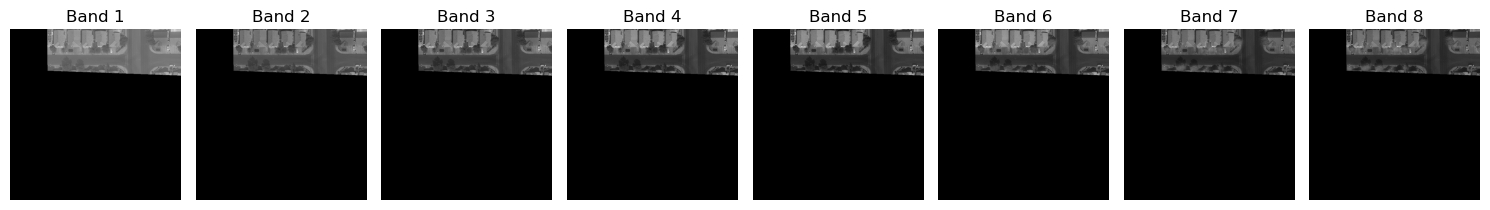

In [57]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Replace with your image path
image_path = "dataset/AOI_2_Vegas_Train/MUL-PanSharpen/MUL-PanSharpen_AOI_2_Vegas_img1.tif"

with rasterio.open(image_path) as src:
    print("Image size: {} x {}".format(src.width, src.height))
    print("Number of bands:", src.count)
    print("CRS:", src.crs)
    print("Transform:", src.transform)

    # Loop over each band and print statistics
    for i in range(src.count):
        band = src.read(i + 1)
        print(f"Band {i+1}: min = {band.min()}, max = {band.max()}, mean = {band.mean()}")

    # Plot each band in a subplot
    fig, axs = plt.subplots(1, src.count, figsize=(15, 5))
    if src.count == 1:
        axs = [axs]
    for i in range(src.count):
        band = src.read(i + 1)
        axs[i].imshow(band, cmap='gray')
        axs[i].set_title(f"Band {i+1}")
        axs[i].axis("off")
    plt.tight_layout()
    plt.show()


Image size: 650 x 650
Number of bands: 8
CRS: EPSG:4326
Transform: | 0.00, 0.00,-115.31|
| 0.00,-0.00, 36.13|
| 0.00, 0.00, 1.00|
Band 1: min = 0, max = 607, mean = 59.25611597633136
Band 2: min = 0, max = 1201, mean = 90.85663905325444
Band 3: min = 0, max = 1772, mean = 120.45412071005917
Band 4: min = 0, max = 1450, mean = 94.72451834319527
Band 5: min = 0, max = 1525, mean = 93.93066035502959


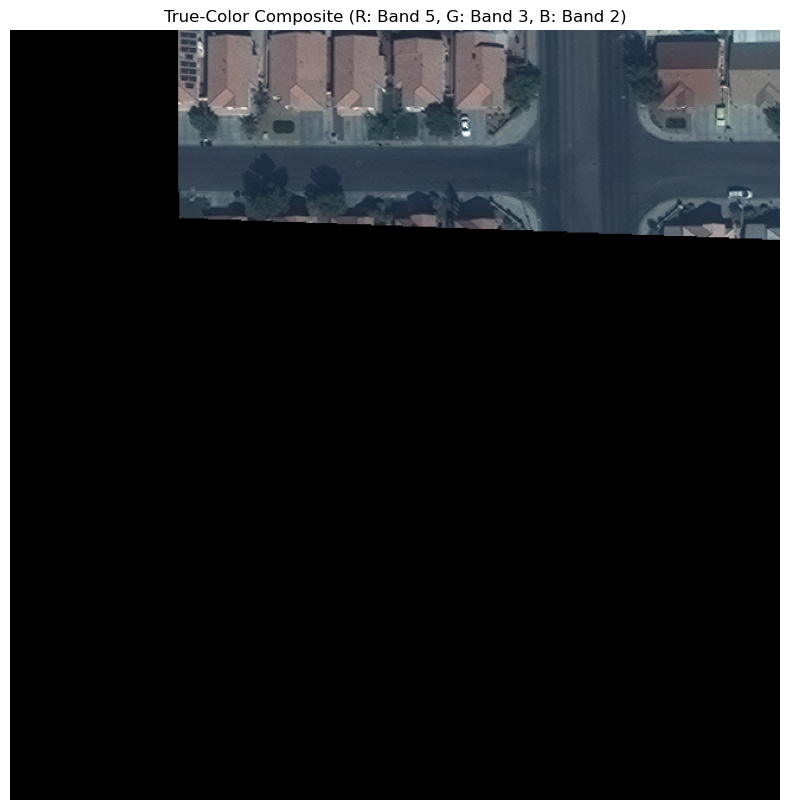

In [58]:
import rasterio
import numpy as np
from matplotlib import pyplot as plt

# Path to the image
image_path = "dataset/AOI_2_Vegas_Train/MUL-PanSharpen/MUL-PanSharpen_AOI_2_Vegas_img1.tif"

def normalize_band(band):
    """Normalize a band to [0, 255]."""
    band_min, band_max = band.min(), band.max()
    if band_max == band_min:
        return np.full_like(band, 128, dtype=np.uint8)
    return ((band - band_min) / (band_max - band_min) * 255).astype(np.uint8)

try:
    with rasterio.open(image_path) as src:
        print(f"Image size: {src.width} x {src.height}")
        print(f"Number of bands: {src.count}")
        print(f"CRS: {src.crs}")
        print(f"Transform: {src.transform}")
        
        # Read and normalize first 5 bands for inspection
        bands = {}
        for i in range(5):
            band = src.read(i + 1)
            bands[i+1] = normalize_band(band)
            print(f"Band {i+1}: min = {band.min()}, max = {band.max()}, mean = {band.mean()}")
        
        # Form a true-color composite using Band 5 (Red), Band 3 (Green), and Band 2 (Blue)
        red = bands[5]
        green = bands[3]
        blue = bands[2]
        rgb_composite = np.stack((red, green, blue), axis=-1)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb_composite)
    plt.title("True-Color Composite (R: Band 5, G: Band 3, B: Band 2)")
    plt.axis("off")
    plt.show()

except FileNotFoundError:
    print(f"Error: The file {image_path} was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


In [ ]:
preprocess_folder_images_only(
    test_folder,
    processed_test_folder
)

## Loading Data

In [ ]:
train_images = []
train_masks = []

In [ ]:
def load_images_and_masks(images_folder, masks_folder):
    """
    Loads preprocessed images and their corresponding masks into NumPy arrays.

    Assumes:
      - images_folder contains .tif image files
      - masks_folder contains .tif mask files
      - Each image "FILE.tif" has a corresponding "FILE_mask.tif" in masks_folder

    Returns:
      X: np.array of shape (N, H, W, C)  [images]
      Y: np.array of shape (N, H, W, 1)  [masks] with dtype float32
    """
    image_paths = sorted(glob.glob(os.path.join(images_folder, "*.tif")))
    X_list = []
    Y_list = []

    for img_path in image_paths:
        # 1) Read the image
        with rasterio.open(img_path) as src_img:
            img_data = src_img.read()  # (bands, height, width)
            img_data = np.transpose(img_data, (1, 2, 0))  # -> (height, width, bands)

        # 2) Build the expected mask filename
        base_name = os.path.splitext(os.path.basename(img_path))[0]  # e.g. "MUL-PanSharpen_AOI_2_Vegas_img4817"
        mask_name = base_name + "_mask.tif"                           # e.g. "MUL-PanSharpen_AOI_2_Vegas_img4817_mask.tif"
        mask_path = os.path.join(masks_folder, mask_name)

        # 3) Read the mask if it exists; else create a blank mask
        if os.path.exists(mask_path):
            with rasterio.open(mask_path) as src_mask:
                mask_data = src_mask.read(1)  # single band -> (height, width)
        else:
            h, w, _ = img_data.shape
            mask_data = np.zeros((h, w), dtype=np.float32)

        X_list.append(img_data.astype(np.float32))
        # Convert the mask to float32 so it matches the predictions’ data type
        Y_list.append(mask_data.astype(np.float32))

    # Convert to NumPy arrays
    X = np.array(X_list, dtype=np.float32)
    Y = np.array(Y_list, dtype=np.float32)
    # Expand dims so mask has shape (N, H, W, 1)
    Y = np.expand_dims(Y, axis=-1)

    return X, Y

In [ ]:
# Load training data

X_train, Y_train = load_images_and_masks(processed_train_folder, processed_mask_folder)

In [ ]:
print("train_images.shape:", X_train.shape)
print("train_masks.shape:", Y_train.shape)

## Modeling

In [ ]:
sm.framework()  # just to confirm

In [ ]:
# I use 'resnext50' as the encoder backbone
# classes=1 for building vs background
# activation='sigmoid' for binary segmentation
# encoder_weights='imagenet' to leverage pretraining
model_resnext = sm.Unet(
    backbone_name='efficientnetb7',
    classes=1,
    activation='sigmoid',
    encoder_weights='imagenet',
    input_shape=(640, 640, 3)
)

In [ ]:
# Compile

# Define the losses.
dice_loss = sm.losses.DiceLoss()  # Dice loss (default is for binary segmentation)
focal_loss = sm.losses.BinaryFocalLoss()  # For a single-class segmentation scenario.

# Combine the losses. The weighting factor (here 1) can be adjusted as needed.
total_loss = dice_loss + focal_loss

model_resnext.compile(
    optimizer='adam',
    loss=total_loss,
    metrics=[
        sm.metrics.FScore(threshold=0.5),       # computes the F1 score (often equivalent to the Dice coefficient)
        sm.metrics.IOUScore(threshold=0.5),       # computes the Intersection over Union (IoU)
    ]
)

# model_resnext.summary()

In [ ]:
history = model_resnext.fit(
    X_train, Y_train,
    epochs=2,
    batch_size=8,
    validation_split=0.25
)

In [ ]:
os.makedirs("outputs", exist_ok=True)
model_save_path = os.path.join("outputs", "unet_efficientnet_building_extraction_multi_spectral.h5")

model_resnext.save(model_save_path)
print(f"Model saved to: {model_save_path}")

In [ ]:
# Plot Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()

In [ ]:
# Plot F-score
plt.figure(figsize=(10, 5))
plt.plot(history.history['f1-score'], label='Train F-score')
plt.plot(history.history['val_f1-score'], label='Validation F-score')
plt.title('Model F-score Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('F-score')
plt.legend(loc='upper right')
plt.show()

In [ ]:
# Plot IoU Score
plt.figure(figsize=(10, 5))
plt.plot(history.history['iou_score'], label='Train IoU')
plt.plot(history.history['val_iou_score'], label='Validation IoU')
plt.title('Model IoU Score Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('IoU Score')
plt.legend(loc='upper right')
plt.show()

## Inference

In [ ]:
def load_images_only(images_folder):
    """
    Loads preprocessed images into a NumPy array.

    Args:
      images_folder (str): Directory containing .tif image files.

    Returns:
      X (np.ndarray): Array of shape (N, H, W, C), 
                      where N = number of images, 
                            H, W = image dimensions,
                            C = number of channels (bands).
    """
    image_paths = sorted(glob.glob(os.path.join(images_folder, "*.tif")))
    X_list = []

    for img_path in image_paths:
        with rasterio.open(img_path) as src_img:
            # Read all bands: shape -> (bands, height, width)
            img_data = src_img.read()
            # Transpose to (height, width, bands) for consistency
            img_data = np.transpose(img_data, (1, 2, 0))
            X_list.append(img_data.astype(np.float32))

    # Convert the list of arrays to a single NumPy array
    X = np.array(X_list, dtype=np.float32)
    return X

In [ ]:
# Load test images
X_test = load_images_only(processed_test_folder)
print("X_train.shape ", X_train.shape)

In [ ]:
preds = model_resnext.predict(X_test)  # shape: (N, 640, 640, 3)
binary_preds = (preds > 0.5).astype('float32')

## Area and Perimeter Calculation

In [ ]:
GSD = 0.31

def compute_area_perimeter(mask_2d, pixel_size=GSD):
    """
    mask_2d: np.array of shape (H, W), binary (0/1)
    pixel_size: ground sampling distance in meters/pixel
    """
    labeled = label(mask_2d)  # identify connected components
    results = []

    for region in regionprops(labeled):
        area_px = region.area
        perimeter_px = region.perimeter

        # Convert to real-world
        area_m2 = area_px * (pixel_size ** 2)
        perimeter_m = perimeter_px * pixel_size

        results.append({
            'label': region.label,
            'area_pixels': area_px,
            'perimeter_pixels': perimeter_px,
            'area_m2': area_m2,
            'perimeter_m': perimeter_m
        })

    return results

In [ ]:
for i in range(len(X_test)):
    mask_2d = binary_preds[i, :, :, 0]
    building_stats = compute_area_perimeter(mask_2d, pixel_size=GSD)
    print(f"Stats for Test Image {i+1}:")
    for stat in building_stats:
        print(stat)
    print("----------------")

In [ ]:
print(f"binary_preds shape: {binary_preds.shape}")
print(f"X_test shape: {X_test.shape}")

## Postprocessing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from skimage.measure import label, regionprops
from matplotlib.patches import Rectangle
import matplotlib.image as mpimg


GSD = 0.31  # Ground Sampling Distance (meters/pixel)

In [ ]:
def compute_area_perimeter(mask_2d, pixel_size=GSD):
    """
    Computes area and perimeter of each connected building in the mask.

    Args:
        mask_2d (np.array): Binary mask (0 = background, 1 = building).
        pixel_size (float): Ground Sampling Distance (meters per pixel).

    Returns:
        List of dictionaries with 'label', 'area_m2', 'perimeter_m'.
    """
    labeled = label(mask_2d)  # Identify connected components
    results = []

    for region in regionprops(labeled):
        area_px = region.area
        perimeter_px = region.perimeter

        # Convert to real-world units
        area_m2 = round(area_px * (pixel_size ** 2), 2)
        perimeter_m = round(perimeter_px * pixel_size, 2)

        results.append({
            'label': region.label,
            'area_m2': area_m2,
            'perimeter_m': perimeter_m,
            'bbox': region.bbox  # Bounding box for annotations
        })

    return results, labeled

In [ ]:
def overlay_mask_with_labels_save(image_path, mask_2d, out_path, alpha=0.4, mask_color='red'):
    """
    Creates and saves an overlay image that shows the input image with a binary mask 
    overlay and annotated building labels.

    Args:
        image_path (str): Path to the original geospatial TIFF image.
        mask_2d (np.array): 2D binary mask (0/1) to overlay.
        out_path (str): File path to save the output figure (e.g. PNG).
        alpha (float): Transparency of the overlay (0 = fully transparent, 1 = fully opaque).
        mask_color (str): Color for the mask overlay (e.g., 'red', 'blue', 'green').
    """
    # Load the image
    with rasterio.open(image_path) as src:
        img_data = src.read()
        img_data = np.transpose(img_data, (1, 2, 0))  # (H, W, C)
        img_data = img_data.astype(np.float32) / 255.0  # Normalize for display

    # Define color mappings for the mask
    color_map = {
        'red': [1, 0, 0, alpha],
        'green': [0, 1, 0, alpha],
        'blue': [0, 0, 1, alpha],
        'yellow': [1, 1, 0, alpha],
        'cyan': [0, 1, 1, alpha]
    }
    overlay_color = color_map.get(mask_color, [1, 0, 0, alpha])

    # Create an overlay mask (RGBA)
    mask_overlay = np.zeros((*mask_2d.shape, 4), dtype=np.float32)
    mask_overlay[mask_2d == 1] = overlay_color

    # Compute building properties (assumes compute_area_perimeter and GSD are defined)
    building_stats, _ = compute_area_perimeter(mask_2d, pixel_size=GSD)

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(img_data)
    ax.imshow(mask_overlay)

    # Annotate detected buildings
    for region in building_stats:
        minr, minc, maxr, maxc = region['bbox']
        rect = Rectangle((minc, minr), maxc - minc, maxr - minr, linewidth=2, edgecolor='white', facecolor='none')
        ax.add_patch(rect)
        label_text = f"ID: {region['label']}\n{region['area_m2']} m²\n{region['perimeter_m']} m"
        ax.text(minc, minr - 5, label_text, fontsize=8, color='white',
                bbox=dict(facecolor='black', alpha=0.6, edgecolor='none'))

    ax.set_title("Image with Mask Overlay & Building Labels")
    ax.axis("off")
    
    # Save the figure instead of showing it
    plt.savefig(out_path, bbox_inches='tight', pad_inches=0.1)
    plt.close(fig)

In [ ]:
images_folder = "dataset/processed_images/AOI_2_Vegas_Test_public/MUL-PanSharpen-processed"

output_folder = "outputs/overlays"
os.makedirs(output_folder, exist_ok=True)

# Get a sorted list of image files
image_files = sorted(glob.glob(os.path.join(images_folder, "*.tif")))

In [ ]:
# Iterate over images and corresponding predicted masks
for idx, image_path in enumerate(image_files):
    # Get the predicted mask from binary_preds
    mask_2d = binary_preds[idx, :, :, 0]
    
    # Define output filename
    base_name = os.path.splitext(os.path.basename(image_path))[0]
    out_file = os.path.join(output_folder, base_name + "_overlay.png")
    
    # Save the overlay image
    overlay_mask_with_labels_save(image_path, mask_2d, out_file, alpha=0.4, mask_color='cyan')
    print(f"Saved overlay for {base_name} to {out_file}")


In [ ]:
img = mpimg.imread("img.jpg")

# Display the image
plt.imshow(img)
plt.show()

Image size: 650 x 650 (Width x Height)
Number of bands: 8
CRS: EPSG:4326
Transform: | 0.00, 0.00,-115.28|
| 0.00,-0.00, 36.15|
| 0.00, 0.00, 1.00|


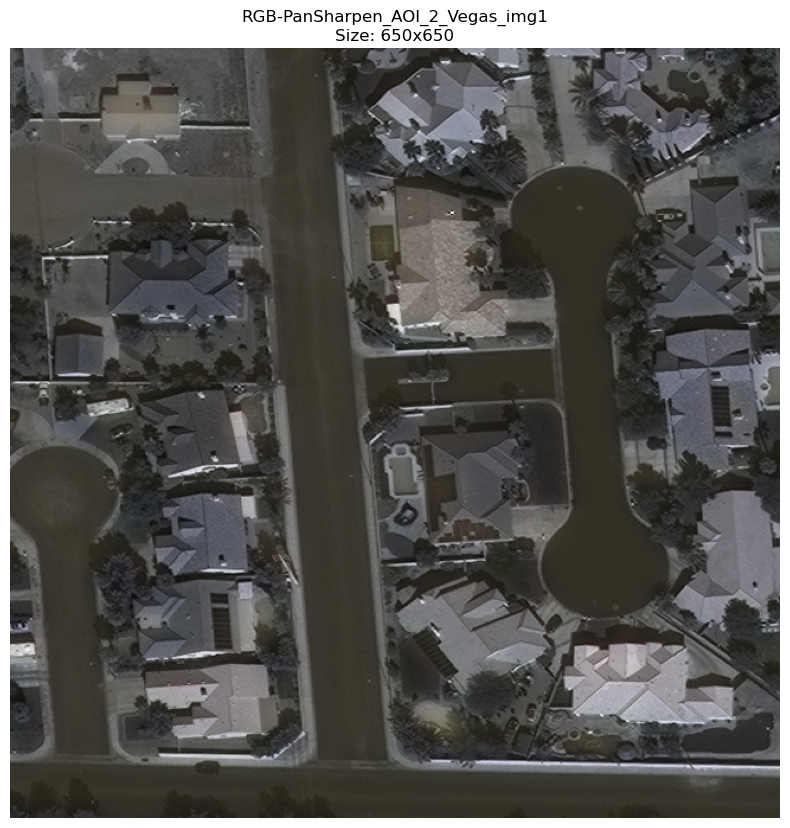

In [27]:
## Visualize the first image

import rasterio
import numpy as np
from matplotlib import pyplot as plt

# Path to the first image
image_path = "dataset/AOI_2_Vegas_Train/MUL-PanSharpen/MUL-PanSharpen_AOI_2_Vegas_img1049.tif"

try:
    # Open the image using Rasterio
    with rasterio.open(image_path) as src:
        # Print image size and metadata
        print(f"Image size: {src.width} x {src.height} (Width x Height)")
        print(f"Number of bands: {src.count}")
        print(f"CRS: {src.crs}")
        print(f"Transform: {src.transform}")

        # Ensure the image has at least 3 bands (R, G, B)
        if src.count < 3:
            raise ValueError("The image does not have enough bands (expected at least 3).")

        # Read the first three bands (R, G, B)
        r = src.read(1)
        g = src.read(2)
        b = src.read(3)

        # Normalize each band individually to the range 0–255
        def normalize_band(band):
            return (band - band.min()) / (band.max() - band.min()) * 255

        r_normalized = normalize_band(r).astype(np.uint8)
        g_normalized = normalize_band(g).astype(np.uint8)
        b_normalized = normalize_band(b).astype(np.uint8)

        # Stack the normalized RGB bands
        rgb_normalized = np.stack((r_normalized, g_normalized, b_normalized), axis=-1)

    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb_normalized)
    plt.title(f"RGB-PanSharpen_AOI_2_Vegas_img1\nSize: {src.width}x{src.height}")
    plt.axis("off")
    plt.show()

except FileNotFoundError:
    print(f"Error: The file {image_path} was not found.")
except ValueError as ve:
    print(f"Error: {ve}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


Image size: 640 x 640 (Width x Height)
Number of bands: 8
CRS: EPSG:4326
Transform: | 0.00, 0.00,-115.28|
| 0.00,-0.00, 36.14|
| 0.00, 0.00, 1.00|


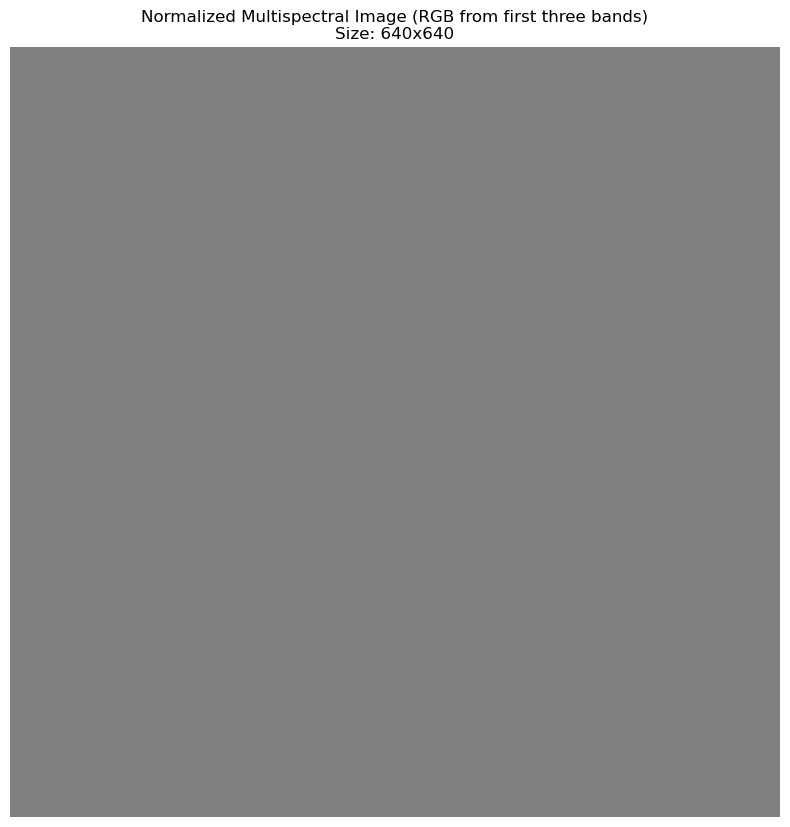

In [30]:
import rasterio
import numpy as np
from matplotlib import pyplot as plt

# Path to the first image
image_path = "dataset/processed_images/AOI_2_Vegas_Train/MUL-PanSharpen-processed/MUL-PanSharpen_AOI_2_Vegas_img1047.tif"

def normalize_band(band):
    """Normalize a band to [0, 255]."""
    band_min, band_max = band.min(), band.max()
    if band_max == band_min:
        return np.full_like(band, 128, dtype=np.uint8)  # Use mid-gray if band is constant
    return ((band - band_min) / (band_max - band_min) * 255).astype(np.uint8)

try:
    # Open the image using Rasterio
    with rasterio.open(image_path) as src:
        # Print image size and metadata
        print(f"Image size: {src.width} x {src.height} (Width x Height)")
        print(f"Number of bands: {src.count}")
        print(f"CRS: {src.crs}")
        print(f"Transform: {src.transform}")

        # Process all bands (not only R, G, B)
        bands = []
        for i in range(src.count):
            band_data = src.read(i + 1)
            norm_band = normalize_band(band_data)
            bands.append(norm_band)
        
        # Stack all normalized bands along the last axis
        full_image = np.stack(bands, axis=-1)  # Shape: (height, width, num_bands)
        
        # For visualization, select the first three bands as RGB if available.
        if full_image.shape[-1] >= 3:
            rgb_image = full_image[..., :3]
        else:
            # If less than 3 bands, replicate the single band.
            rgb_image = np.repeat(full_image, 3, axis=-1)
    
    # Display the image
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb_image)
    plt.title(f"Normalized Multispectral Image (RGB from first three bands)\nSize: {src.width}x{src.height}")
    plt.axis("off")
    plt.show()

except FileNotFoundError:
    print(f"Error: The file {image_path} was not found.")
except ValueError as ve:
    print(f"Error: {ve}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
